In [15]:
import AD_Forward_Backward_Otis as AD
from FunctionGenerator import generate_random_function_b
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

In [ ]:

complexities = np.arange(1, 51)
var_count = 1
n_functions = 100
n_repeats = 100

# setup variables and functions
print("generating functions")
vars = [AD.Var_fb(f"x{i+1}", np.random.uniform(-2,2)) for i in range(var_count)]
functions = [[generate_random_function_b(complexity=c, vars=[vars[0]]) for i in range(n_functions)] for c in complexities]

for c in range(len(complexities)):
    print(functions[c][0])

# time backward mode vs no. of functions
average_times_eval = np.zeros(len(complexities))
average_times_forward = np.zeros(len(complexities))
average_times_backward = np.zeros(len(complexities))
average_times_finitedifferences = np.zeros(len(complexities))
average_times_symbolicderivation = np.zeros(len(complexities))
average_times_symboliceval = np.zeros(len(complexities))

h = 0.0001 # difference used in finite differences

print("timing")
for j in tqdm(range(n_repeats)):
    #random.shuffle(var_counts)
    for c in range(len(complexities)):
        te_total_i = 0
        tf_total_i = 0
        tb_total_i = 0
        tfd_total_i = 0
        tsd_total_i = 0 # symbolic derivation
        tse_total_i = 0 # symbolic evaluation

        for f in functions[c]:

            # evaluation
            start_time = time.time()
            f.eval()
            end_time = time.time()
            te_total_i += end_time - start_time

            # forward AD
            start_time = time.time()
            for k in range(var_count):
                vars[k].forward_partial += 1
                f.derive_forward()
                vars[k].forward_partial -= 1

            end_time = time.time()
            tf_total_i += end_time - start_time

            # backward AD
            start_time = time.time()
            f.eval()
            f.partial = 1
            f.derive()
            end_time = time.time()
            tb_total_i += end_time - start_time

            # finite differences
            start_time = time.time()
            f_0 = f.eval()
            for k in range(var_count):
                vars[k].value += h
                f_xk = f.eval()
                df_dxk_approx = (f_xk - f_0)/h
                vars[k].value -= h
            end_time = time.time()
            tfd_total_i += end_time - start_time
            
            # symbolic derivation
            symbolic_derivatives = []
            start_time = time.time()
            for k in range(var_count):
                symbolic_derivatives.append(f.derive_symbolic(vars[k]))
            end_time = time.time()
            tsd_total_i += end_time - start_time

            # symbolic derivative evaluation
            start_time = time.time()
            for df_fxk in symbolic_derivatives:
                df_fxk.eval()
            end_time = time.time()
            tse_total_i += end_time - start_time

        average_times_eval[c] += (te_total_i/n_functions)
        average_times_forward[c] += (tf_total_i/n_functions)
        average_times_backward[c] += (tb_total_i/n_functions)
        average_times_finitedifferences[c] += (tfd_total_i/n_functions)
        average_times_symbolicderivation[c] += (tsd_total_i/n_functions)
        average_times_symboliceval[c] += (tse_total_i/n_functions)

generating functions


TypeError: only integer scalar arrays can be converted to a scalar index

In [17]:
import pickle

def storeData(fname):
    db = {}
    db['average_times_eval'] = average_times_eval
    db['average_times_forward'] = average_times_forward
    db['average_times_backward'] = average_times_backward
    db['average_times_finitedifferences'] = average_times_finitedifferences
    db['average_times_symbolicderivation'] = average_times_symbolicderivation
    db['average_times_symboliceval'] = average_times_symboliceval

    # Its important to use binary mode
    dbfile = open(fname, 'ab')

    # source, destination
    pickle.dump(db, dbfile)                    
    dbfile.close()

def loadData(fname):
    # for reading also binary mode is important
    dbfile = open(fname, 'rb')    
    db = pickle.load(dbfile)
    for keys in db:
        print(keys, '=>', db[keys])
    dbfile.close()

In [18]:
# uncomment below and run to save times as pickled file
print(complexities)
print(var_count)
print(n_functions)
print(n_repeats)
storeData(f'DataSingleVarVsComplexities/average_times_all_methods_symbolicsimplified01_shuffled c=1-{len(complexities)} v={var_count} n_f={n_functions} n_r={n_repeats}')

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]
1
100
100


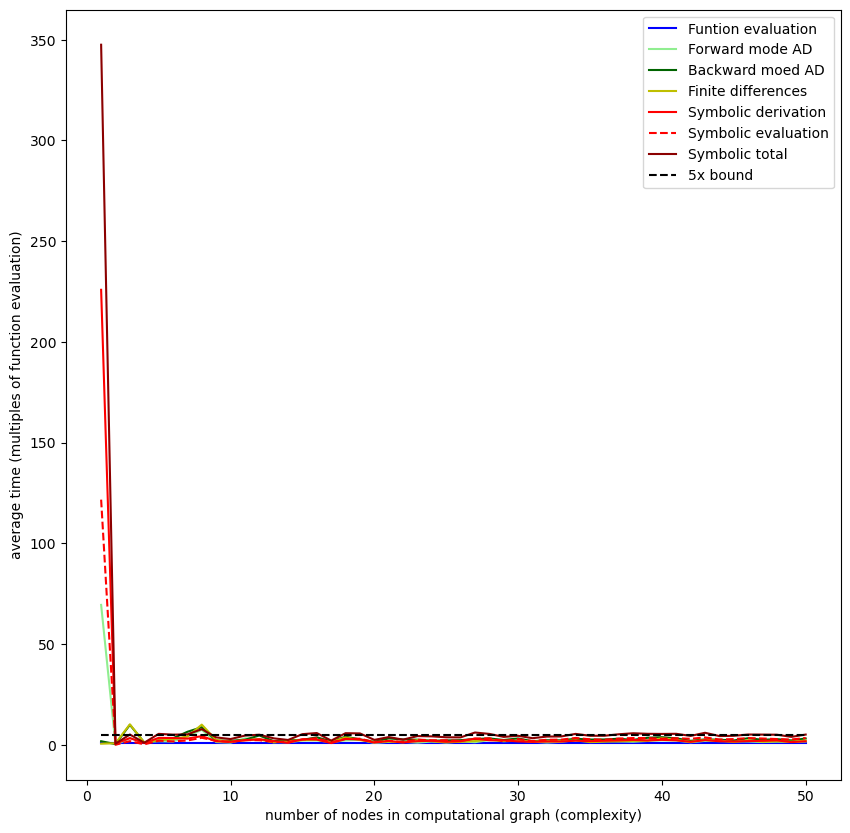

In [19]:
# normalised with symbolic
fig, ax = plt.subplots(figsize=(10,10))
plt.plot(complexities, average_times_eval / average_times_eval, label="Funtion evaluation",c="b")
plt.plot(complexities, average_times_forward / average_times_eval, label="Forward mode AD",c="lightgreen")
plt.plot(complexities, average_times_backward / average_times_eval, label="Backward moed AD", c="darkgreen")
plt.plot(complexities, average_times_finitedifferences / average_times_eval, label="Finite differences", c="y")
plt.plot(complexities, average_times_symbolicderivation / average_times_eval, label="Symbolic derivation", c="r")
plt.plot(complexities, average_times_symboliceval / average_times_eval, label="Symbolic evaluation", c="r", linestyle="--")
plt.plot(complexities, (average_times_symbolicderivation + average_times_symboliceval) / average_times_eval, label="Symbolic total", c="darkred")
plt.plot(complexities, np.ones(len(complexities)) * 5, label="5x bound", c="k",linestyle="--")
plt.xlabel("number of nodes in computational graph (complexity)")
plt.ylabel("average time (multiples of function evaluation)")
plt.legend()
plt.show()


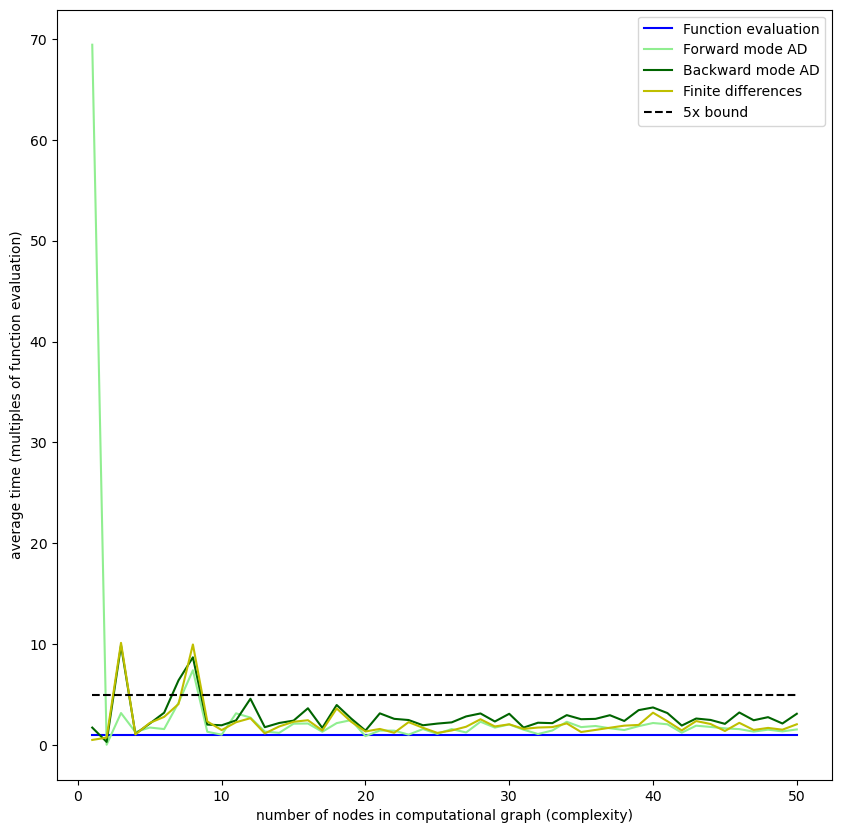

In [20]:

# normalised without symbolic
fig, ax = plt.subplots(figsize=(10,10))
plt.plot(complexities, average_times_eval / average_times_eval, label="Function evaluation",c="b")
plt.plot(complexities, average_times_forward / average_times_eval, label="Forward mode AD",c="lightgreen")
plt.plot(complexities, average_times_backward / average_times_eval, label="Backward mode AD", c="darkgreen")
plt.plot(complexities, average_times_finitedifferences / average_times_eval, label="Finite differences", c="y")
plt.plot(complexities, np.ones(len(complexities)) * 5, label="5x bound", c="k",linestyle="--")
plt.xlabel("number of nodes in computational graph (complexity)")
plt.ylabel("average time (multiples of function evaluation)")
plt.legend()
plt.show()

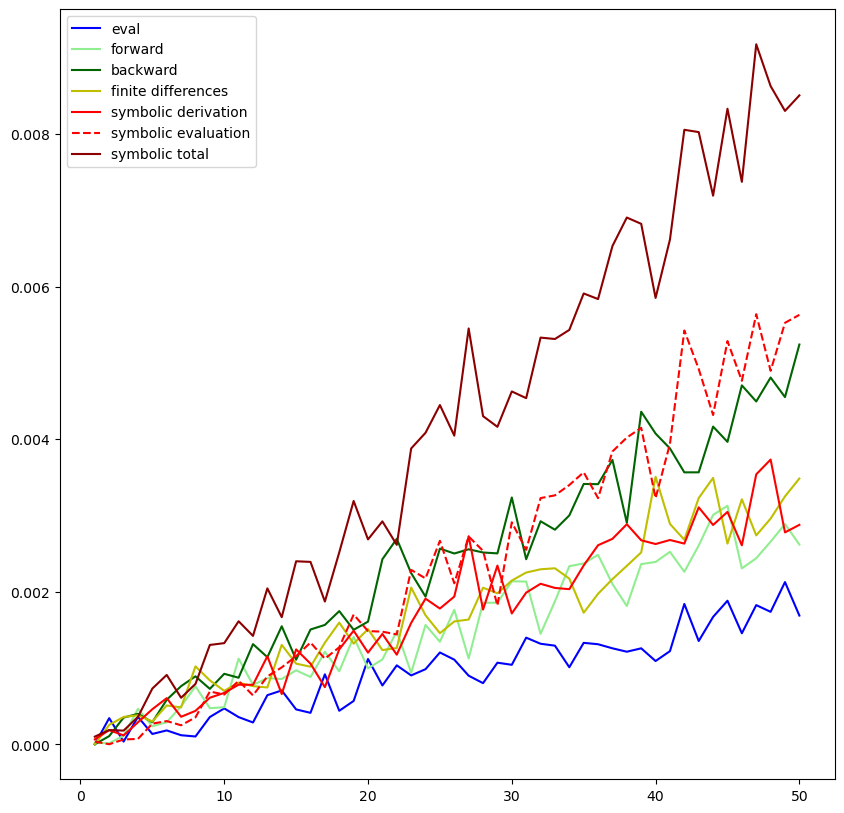

In [21]:
#unnormalised
fig, ax = plt.subplots(figsize=(10,10))

plt.plot(complexities, average_times_eval, label="eval",c="b")
plt.plot(complexities, average_times_forward, label="forward",c="lightgreen")
plt.plot(complexities, average_times_backward, label="backward", c="darkgreen")
plt.plot(complexities, average_times_finitedifferences, label="finite differences", c="y")
plt.plot(complexities, average_times_symbolicderivation, label="symbolic derivation", c="r")
plt.plot(complexities, average_times_symboliceval, label="symbolic evaluation", c="r", linestyle="--")
plt.plot(complexities, average_times_symbolicderivation + average_times_symboliceval, label="symbolic total", c="darkred")

plt.legend()
plt.show()